# GPGN268 - Geophysical Data Analysis
## Data Story 02 - Global Warming

**Student:** Gigi Albers

**Date:** April 16th, 2026

With a global network of around 4,000 autonomous profiling floats, the Argo program offers a "heartbeat" for the world's seas, marking a revolutionary advancement in oceanography. Over the course of a 10-day cycle, these robotic devices continuously measure temperature, salinity, and pressure as they descend to a "park depth" of 1,000 meters to drift with currents, plunge further deeper to 2,000 meters, and then ascend. When they get to the surface, they send this crucial information via satellite before starting the cycle over. These observations, which come from the Global Data Access Centers (GDACs) in France and the USA, are used in this Data Story to investigate the physical condition of the ocean. For scientific purposes, such as initializing climate models, enhancing intensity projections, and tracking ocean heat content, these measurements are essential.

The data is structured as a collection of vertical profiles and trajectories, essentially providing 1D snapshots of the water column that, when aggregated, form a comprehensive 4D (spatial and temporal) view of the global ocean. Distributed primarily in the NetCDF (Network Common Data Form) format, the data offers significant advantages such as being self-describing, machine-independent, and capable of handling multi-dimensional arrays efficiently. However, a potential disadvantage for beginners is the format's complexity, which often requires specialized libraries to decode compared to simple spreadsheets. To interpret this wealth of information, researchers commonly employ tools such as argopy or argoFloats (for Python and R users, respectively) and the Argovis API, which streamline the process of fetching, quality-controlling, and visualizing the data to reveal the hidden dynamics of our changing seas.

In [1]:
import numpy as np, pandas as pd, xarray as xr, matplotlib.pyplot as plt, cartopy as ccrs
from datetime import datetime

In [2]:
ds_raw = xr.load_dataset('5901429_prof.nc')
variables = ['TEMP_ADJUSTED','PSAL_ADJUSTED',
             'LATITUDE', 'LONGITUDE', 'JULD']
# Select relevant variables
ds = ds_raw[variables]

# Rename variables and dimensions for clarity
ds = ds.rename({'JULD':'time'}).swap_dims({'N_PROF':'time'})
# Change variable names to names that are cleaner and easier to type
ds = ds.rename({'TEMP_ADJUSTED':'temperature',
                'PSAL_ADJUSTED':'salinity',
                'LATITUDE':'latitude',
                'LONGITUDE':'longitude'})
# Defining a common pressure coordinate based on the average
# pressure at each level accross all profiles
mean_pressure = ds_raw.PRES_ADJUSTED.mean(dim='N_PROF')
# Create a new variable "pressure" in the dataset and specify the units
ds['pressure'] = mean_pressure
ds['pressure'].attrs['units'] = 'dbar'
# Make "pressure" on of the dimensions (inplace of 'N_LEVELS')
ds = ds.swap_dims({'N_LEVELS':'pressure'})
ds.head()




ds_raw = xr.load_dataset('1901487_prof.nc')
variables = ['TEMP_ADJUSTED','PSAL_ADJUSTED',
             'LATITUDE', 'LONGITUDE', 'JULD']
# Select relevant variables
ds = ds_raw[variables]

# Rename variables and dimensions for clarity
ds = ds.rename({'JULD':'time'}).swap_dims({'N_PROF':'time'})
# Change variable names to names that are cleaner and easier to type
ds = ds.rename({'TEMP_ADJUSTED':'temperature',
                'PSAL_ADJUSTED':'salinity',
                'LATITUDE':'latitude',
                'LONGITUDE':'longitude'})
# Defining a common pressure coordinate based on the average
# pressure at each level accross all profiles
mean_pressure = ds_raw.PRES_ADJUSTED.mean(dim='N_PROF')
# Create a new variable "pressure" in the dataset and specify the units
ds['pressure'] = mean_pressure
ds['pressure'].attrs['units'] = 'dbar'
# Make "pressure" on of the dimensions (inplace of 'N_LEVELS')
ds = ds.swap_dims({'N_LEVELS':'pressure'})
ds.head()



<xarray.Dataset> Size: 340B
Dimensions:      (time: 5, pressure: 5)
Coordinates:
  * time         (time) datetime64[ns] 40B 2010-10-13T09:40:57 ... 2010-11-21...
  * pressure     (pressure) float32 20B 5.0 10.0 15.0 20.0 25.0
Data variables:
    temperature  (time, pressure) float32 100B 28.48 28.46 28.39 ... 28.4 28.4
    salinity     (time, pressure) float32 100B 36.2 36.2 36.2 ... 36.1 36.1 36.1
    latitude     (time) float64 40B 4.443 4.71 4.876 4.996 4.78
    longitude    (time) float64 40B -42.86 -42.64 -42.55 -42.47 -42.14
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2022-07-11T22:47:27Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile

In [3]:
def read_float_data(file_path):
    
    ds_raw = xr.load_dataset(file_path)
    variables = {
        'TEMP_ADJUSTED': 'temperature',
        'PSAL_ADJUSTED': 'salinity',
        'LATITUDE': 'latitude',
        'LONGITUDE': 'longitude',
        'JULD': 'time'
    }
    
    available_vars = [v for v in variables.keys() if v in ds_raw]
    ds = ds_raw[available_vars]
    ds = ds.rename({v: variables[v] for v in available_vars})

    if 'N_PROF' in ds.dims:
        ds = ds.swap_dims({'N_PROF': 'time'})
    
    if 'PRES_ADJUSTED' in ds_raw:
        mean_pressure = ds_raw.PRES_ADJUSTED.mean(dim='N_PROF')
        ds['pressure'] = mean_pressure
        ds['pressure'].attrs['units'] = 'dbar'
        
        if 'N_LEVELS' in ds.dims:
            ds = ds.swap_dims({'N_LEVELS': 'pressure'})
            
    return ds

In [4]:
ds29 = read_float_data('5901429_prof.nc')
ds87 = read_float_data('1901487_prof.nc')

In [5]:
ds29

<xarray.Dataset> Size: 133kB
Dimensions:      (time: 190, pressure: 84)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2006-12-28T01:30:26 ... 2012-06-18...
  * pressure     (pressure) float32 336B 4.974 9.974 14.97 ... 2.05e+03 2.1e+03
Data variables:
    temperature  (time, pressure) float32 64kB 0.146 0.144 0.145 ... 2.212 2.187
    salinity     (time, pressure) float32 64kB 33.79 33.79 33.79 ... 34.77 34.77
    latitude     (time) float64 2kB -62.06 -62.19 -62.36 ... -46.65 -46.88
    longitude    (time) float64 2kB 165.1 165.7 166.8 ... -27.41 -27.49 -27.41
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2019-10-30T22:47:29Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile

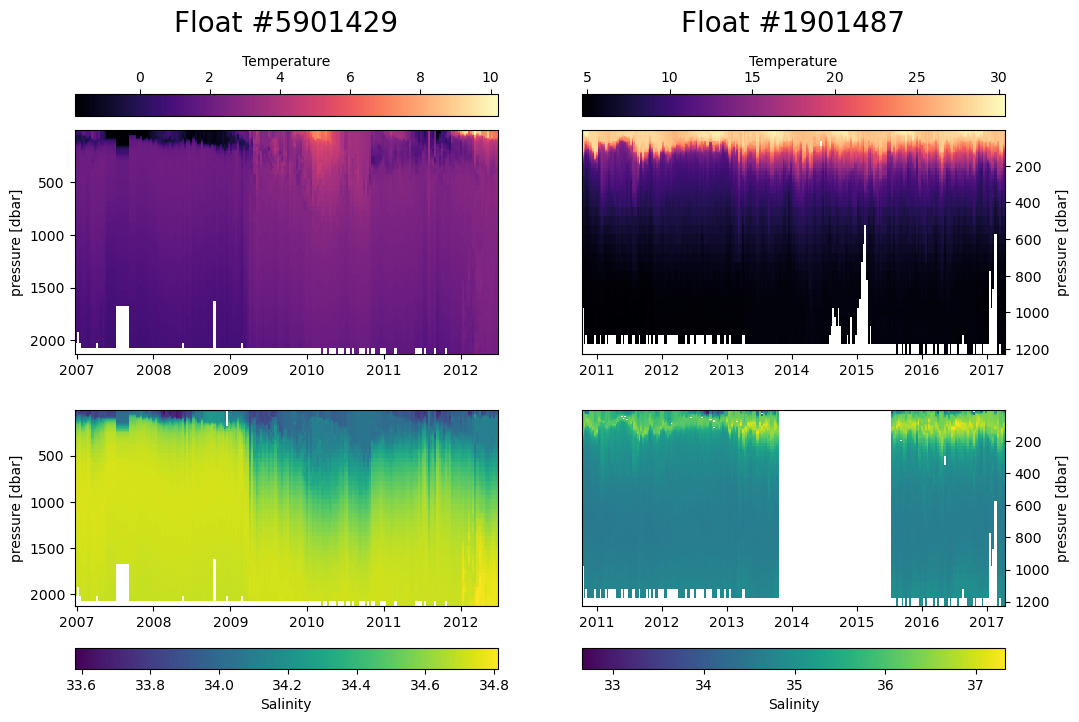

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
[ax1, ax2, ax3, ax4] = axes.flatten()
# Note you will need to transpose the temperature (using .T) to plot
cs1 = ax1.pcolormesh(ds29.time, ds29.pressure, ds29.temperature.T, cmap='magma')
ax1.invert_yaxis()
ax1.set_ylabel('pressure [dbar]')
ax1.set_title("Float #5901429", y=1.4, fontsize=20)
cbar1 = plt.colorbar(cs1, ax=ax1,
                     label='Temperature',
                     orientation='horizontal',
                     location = 'top')

cs2 = ax2.pcolormesh(ds87.time, ds87.pressure, ds87.temperature.T, cmap='magma')
ax2.invert_yaxis()
ax2.set_ylabel('pressure [dbar]')
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_ticks_position("right")
ax2.set_title("Float #1901487", y=1.4, fontsize=20)
cbar2 = plt.colorbar(cs2, ax=ax2,
                     label='Temperature',
                     orientation='horizontal',
                     location = 'top')

cs3 = ax3.pcolormesh(ds29.time, ds29.pressure, ds29.salinity.T, cmap='viridis')
ax3.invert_yaxis()
ax3.set_ylabel('pressure [dbar]')
cbar1 = plt.colorbar(cs3, ax=ax3,
                     label='Salinity',
                     orientation='horizontal',
                     location = 'bottom')

cs4 = ax4.pcolormesh(ds87.time, ds87.pressure, ds87.salinity.T, cmap='viridis')
ax4.invert_yaxis()
ax4.set_ylabel('pressure [dbar]')
ax4.yaxis.set_label_position("right")
ax4.yaxis.set_ticks_position("right")
cbar4 = plt.colorbar(cs4, ax=ax4,
                     label='Salinity',
                     orientation='horizontal',
                     location = 'bottom')

## Task 2.3 – Float trajectories

In [7]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

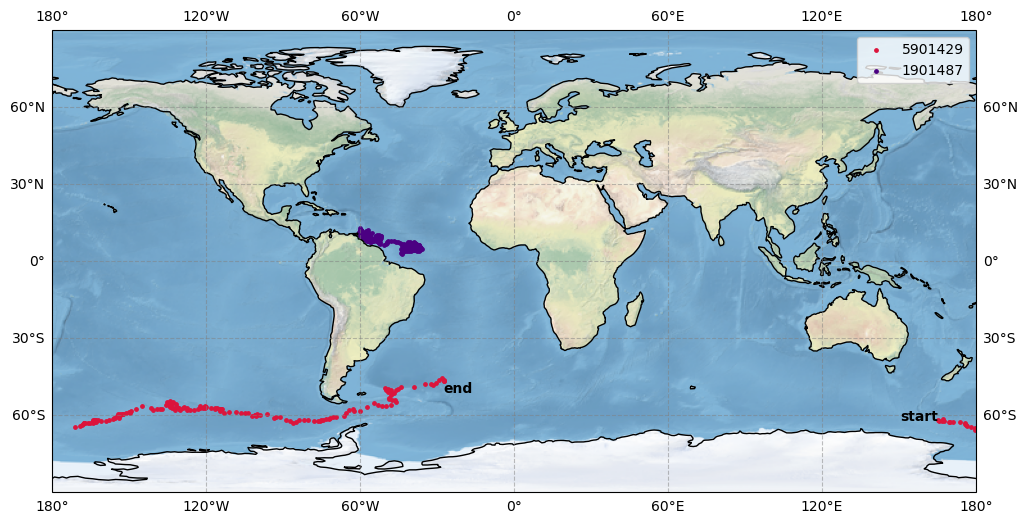

In [8]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.stock_img()
ax.coastlines()

ax.scatter(ds29.longitude, ds29.latitude, color='crimson', s=6, label='5901429', transform=ccrs.PlateCarree())
ax.scatter(ds87.longitude, ds87.latitude, color='indigo', s=6, label='1901487', transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
gl.top_labels = True
gl.right_labels = True

ax.text(ds29.longitude.values[0], ds29.latitude.values[0], 'start', 
        transform=ccrs.PlateCarree(), fontweight='bold', ha='right')

ax.text(ds29.longitude.values[-1], ds29.latitude.values[-1], 'end', 
        transform=ccrs.PlateCarree(), fontweight='bold', va='top')

plt.legend(loc='upper right', frameon=True)
plt.show()

## Task 2.4 – Interpreting ocean temperature and salinity

The temperature sections show a clear pattern of warm surface water and much colder temperatures at depth. Both floats have a strong thermocline in the upper few hundred meters, where temperature drops quickly with depth. Below around 500–800 dbar, the temperature becomes more uniform. There are also clear differences between the two floats. Float 1901487, which stays in the tropics, has very warm surface temperatures (around 25–30°C) and is relatively stable over time. On the other hand, float 5901429, located in the Southern Ocean, is much colder overall and shows more variability, which makes sense given the harsher conditions there.

The salinity plots also differ between the two locations. The tropical float has higher salinity near the surface, likely due to strong evaporation, while the southern float has lower salinity, probably from precipitation and freshwater input. At deeper levels, salinity becomes more consistent for both floats. Overall, these patterns match what we would expect: warm, stable conditions in the tropics and cooler, more variable conditions at higher latitudes.

## Task 2.5 – Average temperature and salinity profiles

The average temperature profile for float 1901487 shows a strong decrease with depth, going from about 27°C at the surface to near 5°C deeper down. This sharp change in the upper ocean is the thermocline. The salinity profile shows a slight maximum near the surface and then decreases gradually with depth. These patterns reflect surface processes like heating and evaporation, while deeper water stays more stable.

The confidence intervals are wider near the surface, which suggests more variability there, and much narrower at depth. However, the assumption that all time points are independent is not really accurate. Ocean data tends to be correlated over time, so measurements close together aren’t fully independent. Because of this, the confidence intervals are probably a bit too small. A better approach would be to account for autocorrelation, which would likely increase the uncertainty.

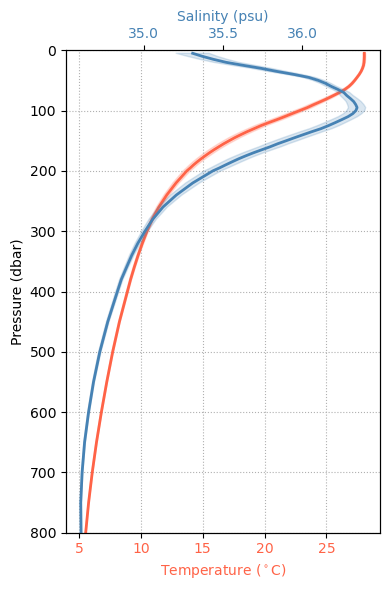

In [ ]:
tropic_temp = ds87.temperature
tropic_sal = ds87.salinity

mean_temp = tropic_temp.mean(dim='time')
mean_sal = tropic_sal.mean(dim='time')

n = ds87.time.size
temp_std = tropic_temp.std(dim='time')
sal_std = tropic_sal.std(dim='time')

temp_ci = 1.96 * (temp_std / np.sqrt(n))
sal_ci = 1.96 * (sal_std / np.sqrt(n))

fig, ax1 = plt.subplots(figsize=(4, 6))
color = 'tomato'
ax1.plot(mean_temp, ds87.pressure, color=color, lw=2)

ax1.fill_betweenx(ds87.pressure, mean_temp - temp_ci, mean_temp + temp_ci, 
                  color=color, alpha=0.2)
ax1.set_xlabel(r'Temperature ($^\circ$C)', color=color)
ax1.set_ylabel('Pressure (dbar)')
ax1.set_ylim([0, 800])
ax1.invert_yaxis()
ax1.tick_params(axis='x', labelcolor=color)
ax1.grid(ls='dotted', which='both')

ax2 = ax1.twiny()
color = 'steelblue'
ax2.plot(mean_sal, ds87.pressure, color=color, lw=2)

ax2.fill_betweenx(ds87.pressure, mean_sal - sal_ci, mean_sal + sal_ci, 
                  color=color, alpha=0.2)

ax2.set_xlabel('Salinity (psu)', color=color)
ax2.tick_params(axis='x', labelcolor=color)

plt.tight_layout()
plt.show()

## Task 3.1 – Reading and processing climatology data

In [10]:
import hvplot.xarray
import holoviews as hv
hv.extension('bokeh')

ds = xr.open_dataset('RG_ArgoClim_Temperature_2019.nc', decode_times=False)
t0 = np.datetime64("2004-01")
months = range(len(ds.TIME))
time = np.array([t0 + np.timedelta64(m, "M") for m in months])

ds = ds.rename({
    'TIME': 'time',
    'ARGO_TEMPERATURE_MEAN': 'temp_mean',
    'ARGO_TEMPERATURE_ANOMALY': 'temp_anom',
    'PRESSURE': 'pressure',
    'LATITUDE': 'latitude',
    'LONGITUDE': 'longitude'
})

ds['time'] = time
depth_ave_temp = ds.temp_anom.mean(dim='pressure')
plot = depth_ave_temp.hvplot('longitude', 'latitude', cmap='RdBu_r', clim=(-3, 3))
print("New time coordinate example:", ds.time.values[0:3])
plot


New time coordinate example: ['2004-01-01T00:00:00' '2004-02-01T00:00:00' '2004-03-01T00:00:00']


BokehModel(combine_events=True, render_bundle={'docs_json': {'4c8459dd-1e23-4841-93be-f3fcb612c463': {'version…

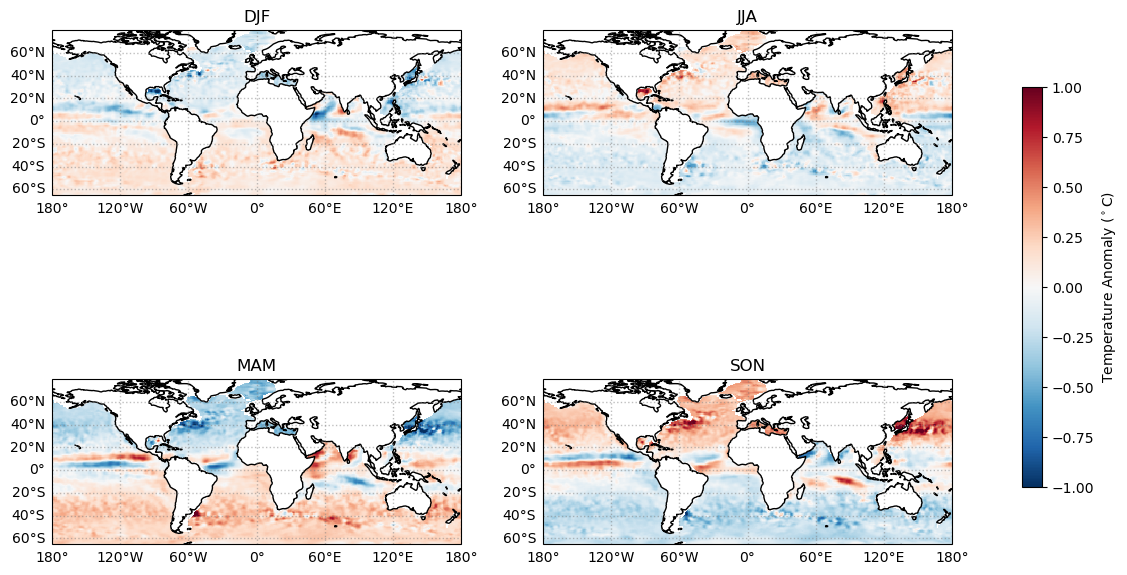

In [11]:
seasonal_temp = depth_ave_temp.groupby("time.season").mean()

vmin = -1
vmax = 1

fig, axes = plt.subplots(2, 2, figsize=(10, 8), 
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, s in enumerate(seasonal_temp.season):
    ax = axes[i]
    
    data_slice = seasonal_temp.sel(season=s)
    
    cs = ax.pcolormesh(ds.longitude, ds.latitude, data_slice,
                       transform=ccrs.PlateCarree(),
                       vmin=vmin, vmax=vmax, cmap='RdBu_r', 
                       shading='auto')
    
    ax.set_title(s.values)
    ax.coastlines()
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray',
                      alpha=0.5, linestyle='dotted')
    gl.top_labels = False
    gl.right_labels = False

cax = fig.add_axes([1.02, 0.25, 0.02, 0.5]) 
cbar = plt.colorbar(cs, cax=cax, label=r'Temperature Anomaly ($^\circ$C)')

fig.subplots_adjust(bottom=0.1, top=0.9, left=0.05, right=0.95,
                    wspace=0.2, hspace=0.2)

plt.show()

The seasonal maps show how temperature anomalies change throughout the year across the globe. There are clear differences between seasons, with warmer anomalies appearing in the hemisphere experiencing summer and cooler ones during winter. For example, the Northern Hemisphere is warmer in JJA, while the Southern Hemisphere shows warming during its own summer months. The tropics don’t change as much, which suggests more stable conditions there.

These patterns are mainly driven by changes in solar radiation due to Earth’s tilt. Even though the ocean absorbs and stores heat, we can still see the seasonal cycle pretty clearly. Ocean circulation probably also plays a role in how these anomalies are distributed, although its harder to see directly from the plots.

The hypothesis testing results show which areas have temperature anomalies that are significantly different from zero. Regions without hatching indicate statistically significant results, meaning there is a consistent seasonal signal. Hatched regions show where we cannot reject the null hypothesis, so the anomalies there might just be due to variability.

However, the assumption that each time point is independent is not very strong. Ocean temperatures are usually correlated over time, so this likely affects the results. Because of that, the significance might be slightly overestimated. If we accounted for this properly, there would probably be more areas that are not statistically significant.

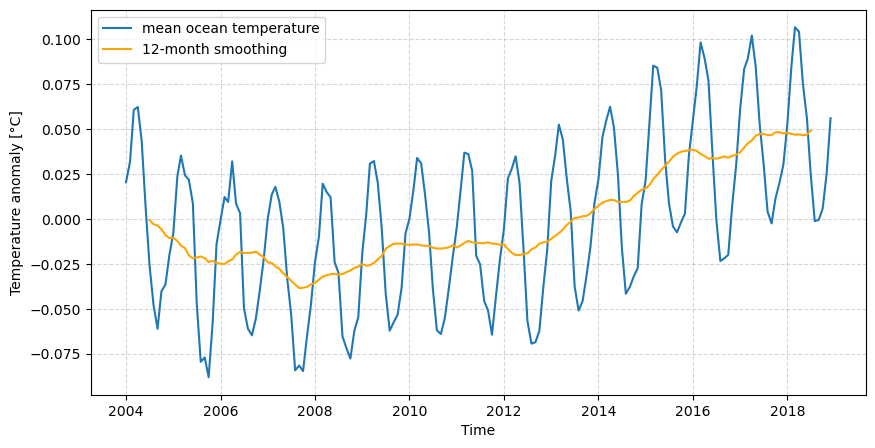

In [12]:
ds = xr.open_dataset('RG_ArgoClim_Temperature_2019.nc', decode_times=False)

t0 = np.datetime64("2004-01")
months = range(len(ds.TIME))
time = np.array([t0 + np.timedelta64(m, "M") for m in months])

ds = ds.rename({
    'TIME': 'time',
    'ARGO_TEMPERATURE_MEAN': 'temp_mean',
    'ARGO_TEMPERATURE_ANOMALY': 'temp_anom',
    'PRESSURE': 'pressure',
    'LATITUDE': 'latitude',
    'LONGITUDE': 'longitude'
})

ds['time'] = time

depth_ave_temp = ds.temp_anom.mean(dim='pressure')

global_mean = depth_ave_temp.mean(dim=['latitude', 'longitude'])
running_mean = global_mean.rolling(time=12, center=True).mean()

plt.figure(figsize=(10,5))

plt.plot(global_mean.time, global_mean, label='mean ocean temperature')
plt.plot(running_mean.time, running_mean, label='12-month smoothing', color='orange')

plt.ylabel('Temperature anomaly [°C]')
plt.xlabel('Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

The time series of global mean ocean temperature anomaly shows both strong seasonal variability and a clear long-term warming trend. The raw data exhibit regular oscillations corresponding to the annual cycle, while the 12-month smoothed curve highlights the underlying trend. From approximately 2004 to 2012, the data show a relatively flat or slightly decreasing trend, often referred to as a “hiatus” period. However, after around 2012, there is a noticeable and sustained increase in temperature anomalies, indicating accelerated ocean warming.

From the graph, the temperature increases by about 0.06°C between 2012 and 2018, which gives an estimated trend of roughly 0.1°C per decade. This is in line with values reported in other studies, which usually fall between 0.05 and 0.1°C per decade. Overall, the data clearly shows that the ocean is warming, even though there is some short-term variability.